In [1]:
import yaml, torch, sys, json, random, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from types import SimpleNamespace
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
sys.path.insert(0, '../../')
from utils.train_model import run_experiment, set_seed, get_device

In [2]:
def to_namespace(d):
    if isinstance(d, dict):
        return SimpleNamespace(**{k: to_namespace(v) for k, v in d.items()})
    return d

with open('../../configs/defaults.yaml') as f:
    config = yaml.safe_load(f)

with open('../../configs/EX_03_03.yaml') as f:
    config.update(yaml.safe_load(f))

config = to_namespace(config)
set_seed(config.seed)
device = get_device()
RAW_DIR  = Path(config.raw_dir)
GRAD_DIR = Path(config.grad_dir)
data_dir = Path('./EX_03_03/Raw/')

[device] using cuda


# Context
......
# Code


In [3]:
def box_blur(x, kernel_size=9):
    channels = x.shape[1]
    kernel = torch.ones(channels, 1, kernel_size, kernel_size, 
                        device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size//2, groups=channels)

In [4]:

from PIL import Image, ImageFont, ImageDraw
GLYPH_CHARS = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789")
SPECIAL_CHARS = list("#$%&@")

FONT_PATHS = {
    "sans":  "../../shared_models/assets/Helvetica.ttf",
    "serif": "../../shared_models/assets/AppleGaramond.ttf",
}

# (char, font_key) pairs — lets you restrict weird chars to fonts they render cleanly in
GLYPH_FONT_PAIRS = (
    [(c, "sans")  for c in GLYPH_CHARS] +
    [(c, "serif") for c in GLYPH_CHARS]
)

SPECIAL_FONT_PAIRS = (
    [(c, "sans") for c in SPECIAL_CHARS]  # only sans for specials, serif can be weird
)

def glyph_bgrnd(size, bg_type):
    if bg_type == "blank":
        return torch.zeros(3, size, size)
    else:
        raise ValueError(f"unknown bg_type: {bg_type}")

class fontOnlyDataset(Dataset):
    def __init__(self, num_samples=60000, size=28, special_freq=0.05):
        self.num_samples  = num_samples
        self.size         = size
        self.special_freq = special_freq
        self.fonts        = {k: ImageFont.truetype(v, size=round(size * 0.999)) 
                             for k, v in FONT_PATHS.items()}

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        if random.random() < self.special_freq:
            char, font_key = random.choice(SPECIAL_FONT_PAIRS)
            label = len(GLYPH_CHARS) + SPECIAL_CHARS.index(char)
        else:
            char, font_key = random.choice(GLYPH_FONT_PAIRS)
            label = GLYPH_CHARS.index(char)

        font = self.fonts[font_key]
        img  = Image.new("L", (self.size, self.size), 0)
        draw = ImageDraw.Draw(img)
        bbox = draw.textbbox((0, 0), char, font=font)
        x = (self.size - (bbox[2] - bbox[0])) // 2 - bbox[0]
        y = (self.size - (bbox[3] - bbox[1])) // 2 - bbox[1]
        draw.text((x, y), char, fill=255, font=font)

        glyph = TF.to_tensor(img)
        background = glyph_bgrnd(self.size, config.glyph_bkgrnd)
        comp = torch.cat([background, glyph], dim=0)
        target_color = torch.rand(3)  # random color per sample
        return comp, label, target_color

# n = 100
n = 60000 #full size
ex03_03a_trainset = fontOnlyDataset(num_samples = n)
train_size = int(0.9 * n)
val_size   = n - train_size
train_set, val_set = random_split(ex03_03a_trainset, [train_size, val_size],
                                  generator=torch.Generator().manual_seed(config.seed))
ex03_03a_trainloader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True)
ex03_03a_valloader   = DataLoader(val_set,   batch_size=config.batch_size)

NUM_CLASSES = len(GLYPH_CHARS) + len(SPECIAL_CHARS)


ValueError: too many values to unpack (expected 2)

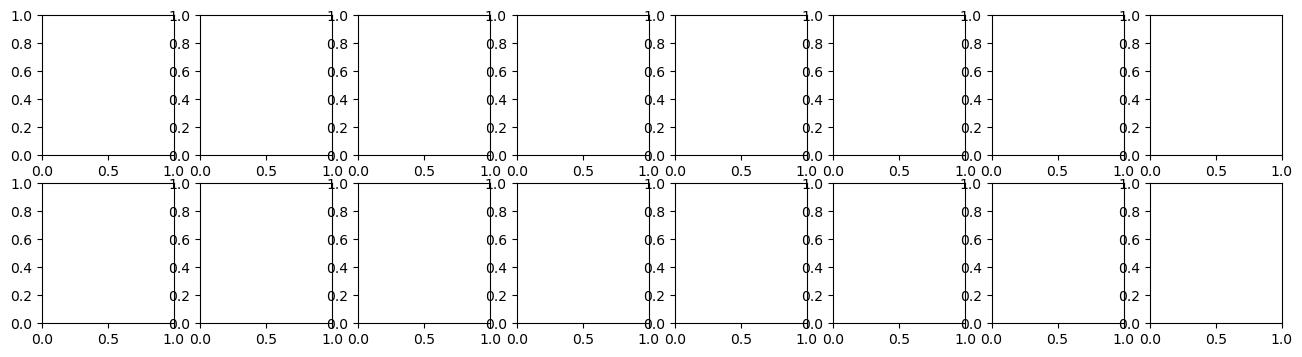

In [5]:
ds = fontOnlyDataset(num_samples=100)
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for ax in axes.flat:
    comp, label = ds[random.randint(0, len(ds)-1)]
    img = comp[3]
    char = (GLYPH_CHARS + SPECIAL_CHARS)[label]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(char)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
def bandwtn(image):
    # image shape: (B, C, H, W)
    if image.shape[1] == 3:
        gray = (
            0.299 * image[:, 0:1] +
            0.587 * image[:, 1:2] +
            0.114 * image[:, 2:3]
        )
        # repeat to 3 channels to match input
        return gray.repeat(1, 3, 1, 1)
    
    elif image.shape[1] == 1:
        # already grayscale, just return
        return image
    
    else:
        raise ValueError(f"Unsupported number of channels: {image.shape[1]}")

In [9]:
from transformers import AutoImageProcessor, SiglipForImageClassification

style_model = SiglipForImageClassification.from_pretrained("prithivMLmods/WikiArt-Style").to(device)
style_processor = AutoImageProcessor.from_pretrained("prithivMLmods/WikiArt-Style")
style_model.eval()

POLLOCK_LABELS = [1, 3]  # "Abstract Expressionism", "Action painting" — verify indices

def pollock_loss(generated):
    # generated: (B, 3, 28, 28), needs upscaling for the processor
    upscaled = F.interpolate(generated, size=(224, 224), mode="bilinear")
    inputs = style_processor(images=upscaled, return_tensors="pt", do_rescale=False).to(device)
    with torch.no_grad():  # freeze, we just want the gradient through the score
        logits = style_model(**inputs).logits
    pollock_score = logits[:, POLLOCK_LABELS].sum(dim=1)
    return -pollock_score.mean()  # maximize pollock-ness

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [10]:
#mnist classifier and data loading
#this remains a 3 channel classifier, as in both pre- and post-, we sum the image before classification
class LeNet3channel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, NUM_CLASSES)

    def forward(self, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        x = F.avg_pool2d(F.relu(self.conv1(x)), 2)
        x = F.avg_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))

def alpha_combine(b, i):
    alpha = i.expand_as(b)
    comp = alpha * i.expand_as(b) + (1 - alpha) * b
    return comp
    
def additive_combine(b, i):
    """
    b: (B, 3, H, W) background
    i: (B, 1, H, W) or (B, 3, H, W) digit
    returns: (B, 3, H, W) composite, clamped
    """
    return (b + i.expand_as(b)).clamp(0, 1)

In [11]:
#model

class singleBlock0cBlurredGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(NUM_CLASSES+2, 128),
            nn.ReLU(),
            nn.Linear(128, 7*7*32),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),   # 28x28
            nn.Sigmoid()
        )
    
    def forward(self, label_onehot):
        return self.net(label_onehot)



def ex3_03a_loss_fn(batch, model, epoch, total_epochs, mode="train", **kwargs):
    # b, i, label, b_idx, i_idx = batch
    comp, label = batch
    b, i  = comp[:, :3], comp[:, 3:]
    noise   = torch.randn(label.shape[0], 2).to(device)
    onehot = F.one_hot(label, num_classes=NUM_CLASSES).float()
    x       = torch.cat([onehot, noise], dim=1)
    generated = model(x)
    
    conf_pre, pred_pre  = m_classify_3d_with_conf(generated, label)

    #curriculum bit
    t = epoch / config.variants.a.epochs

    pollock_curriculum = max(0.0, (t - 0.4) / 0.6)       # kicks in at epoch 5/10
    confpre_curriculum = max(0.0, (t - 0.80) / 0.20)     # kicks in at epoch 8/10
    
    polluck_w = config.variants.a.gamma * pollock_curriculum #thinking this should back off when confpre comes in, we'll see for next expeirment
    confpre_w = config.variants.a.alpha * confpre_curriculum
    confpost_w = config.variants.a.beta
    
    

    #polluck loss
    polluck_loss = pollock_loss(generated).clamp(-1, 0) #needs clamping bc negative loss is killilng us. it overwhelms when it shouldn't

    generated_1d = generated.max(dim=1, keepdim=True).values
    # trying loss with no blurr anymore, and now just the mask thing.
    bandwtn_unblurred = bandwtn(generated_1d)
    mask = (i > 0.5)  # True where glyph is
    post_loss = F.mse_loss(bandwtn_unblurred[mask], i[mask])

    delta_vis = (confpost_w * post_loss +
                 confpre_w * conf_pre +
                 polluck_w * polluck_loss
    )
    loss = (delta_vis).mean() if delta_vis.dim() > 0 else delta_vis
    if mode == "val":
        return {
            "val_loss":     loss.item(),
            "uw_pre_loss":     conf_pre.mean().item(),
            "uw_post_loss":    post_loss.item(),
            "uw_polluck_loss": polluck_loss.item(),
            "polluck_w":    polluck_w,
            "pre_loss_w":    confpre_w,
        }
    return loss


# ── RUN ───────────────────────────────────────────────────────────────────────
ex_03_03a_info = {
    "exp_id":      "EX_03_03a",
    "epochs":      config.variants.a.epochs,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/A",
    "log_dir":     "logs/A",
    "seed":        42,
    "notes": config.variants.a.description
}

model_03_03a = singleBlock0cBlurredGenerator()
optimizer = torch.optim.Adam(model_03_03a.parameters(), lr=config.lr)

b_model = LeNet3channel().to(device)
b_model.load_state_dict(torch.load('../../shared_models/font_glyph_classifier/font_glyph_classifier.pt', map_location=device, weights_only=True))
b_model.eval()


def m_classify_3d_with_conf(image, correct):
    if image.shape[1] != 3:
        raise Exception(f"expected a 3 dim image, got a image of shape {image.shape}")
    # with torch.no_grad():
    logits = b_model(image)
    preds = torch.softmax(logits, dim=1)
    max_pred = torch.argmax(logits, dim=1)
    return preds[torch.arange(preds.shape[0]), correct], max_pred



In [12]:
run_experiment(
    model=model_03_03a,
    optimizer=optimizer,
    loss_fn=ex3_03a_loss_fn,
    train_loader=ex03_03a_trainloader,
    val_loader=ex03_03a_valloader,
    config=ex_03_03a_info,
    log_to=ex_03_03a_info["log_to"],
)


<All keys matched successfully>

In [19]:
def show_generated(model, dataset, n=4, device=device):
    model.eval()
    fig, axes = plt.subplots(n, 5, figsize=(15, n*3))
    
    with torch.no_grad():
        for row in range(n):
            comp, label_int, target_color = dataset[random.randint(0, len(dataset)-1)]
            label  = torch.tensor([label_int]).to(device)
            i      = comp[3:].unsqueeze(0).to(device)  # real digit (1, 1, 28, 28)
            
            noise   = torch.randn(1, 2).to(device)
            onehot  = F.one_hot(label, num_classes=NUM_CLASSES).float()
            x       = torch.cat([onehot, noise], dim=1)
            
            generated    = model(x)
            generated_1d = generated.mean(dim=1, keepdim=True)
            blurred_gen  = box_blur(generated_1d)
            blurred_real = box_blur(i, kernel_size=3) #no-op
            post_loss    = F.mse_loss(blurred_gen, blurred_real).item()
            
            conf_pre, pred_pre = m_classify_3d_with_conf(generated, label)

            axes[row, 0].imshow(i.squeeze().cpu(), cmap="gray")
            axes[row, 0].set_title(f"real digit (label={label_int})")
            color_patch = target_color.cpu().numpy()
            axes[row, 1].imshow([[color_patch]])
            axes[row, 1].set_title("target_color")
            axes[row, 2].imshow(generated.squeeze(0).cpu().permute(1,2,0))
            axes[row, 2].set_title(f"generated | pre conf={conf_pre.item():.3f} pred={pred_pre.item()}")
            axes[row, 3].imshow(blurred_gen.squeeze().cpu(), cmap="gray")
            axes[row, 3].set_title(f"gen blurred | mse={post_loss:.4f}")
            axes[row, 4].imshow((blurred_gen - blurred_real).squeeze().cpu(), cmap="RdBu")
            axes[row, 4].set_title("difference")
            for ax in axes[row]: ax.axis("off")
    
    plt.tight_layout()
    plt.savefig("Results/EX04_generated.png")
    plt.close()
    
    from IPython.display import Image as IPImage, display
    display(IPImage("Results/EX04_generated.png"))

# show_generated(model_03_03a, train_set)

In [20]:
#model

class singleBlock0cBlurredGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(NUM_CLASSES+2, 128),
            nn.ReLU(),
            nn.Linear(128, 7*7*32),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),   # 28x28
            nn.Sigmoid()
        )
    
    def forward(self, label_onehot):
        return self.net(label_onehot)



def ex3_03b_loss_fn(batch, model, epoch, total_epochs, mode="train", **kwargs):
    # b, i, label, b_idx, i_idx = batch
    comp, label, target_color = batch
    b, i  = comp[:, :3], comp[:, 3:]
    noise   = torch.randn(label.shape[0], 2).to(device)
    onehot = F.one_hot(label, num_classes=NUM_CLASSES).float()
    x       = torch.cat([onehot, noise], dim=1)
    generated = model(x)
    
    conf_pre, pred_pre  = m_classify_3d_with_conf(generated, label)

    #curriculum bit
    t = epoch / config.variants.b.epochs

    pollock_curriculum = max(0.0, (t - 0.4) / 0.6)       # kicks in at epoch 5/10
    confpre_curriculum = max(0.0, (t - 0.80) / 0.20)     # kicks in at epoch 8/10
    
    polluck_w = config.variants.b.gamma * pollock_curriculum #thinking this should back off when confpre comes in, we'll see for next expeirment
    confpre_w = config.variants.b.alpha * confpre_curriculum
    confpost_w = config.variants.b.beta
    bg_loss_w = config.variants.b.delta
    
    

    #polluck loss
    polluck_loss = pollock_loss(generated).clamp(-1, 0) #needs clamping bc negative loss is killilng us. it overwhelms when it shouldn't

    generated_1d = generated.max(dim=1, keepdim=True).values
    blurred_gen  = box_blur(generated_1d)
    bandwtn_unblurred = bandwtn(blurred_gen)
    glyph_mask = (i > 0.5)  # True where glyph is
    bg_mask    = ~glyph_mask

    glyph_loss = F.mse_loss(blurred_gen[glyph_mask], i[glyph_mask])
    bg_pixels = generated[:, :, bg_mask[0, 0]]  # (B, 3, N)
    target = target_color.to(device).unsqueeze(-1)  # (B, 3, 1)
    bg_loss = F.mse_loss(bg_pixels, target.expand_as(bg_pixels))
    
    post_loss = glyph_loss + (bg_loss_w * bg_loss)

    delta_vis = (confpost_w * post_loss +
                 confpre_w * conf_pre +
                 polluck_w * polluck_loss
    )
    loss = (delta_vis).mean() if delta_vis.dim() > 0 else delta_vis
    if mode == "val":
        return {
            "val_loss":     loss.item(),
            "uw_pre_loss":     conf_pre.mean().item(),
            "uw_post_loss":    post_loss.item(),
            "uw_polluck_loss": polluck_loss.item(),
            "uw_bg_loss": bg_loss.item(),
            "polluck_w":    polluck_w,
            "pre_loss_w":    confpre_w,
        }
    return loss


# ── RUN ───────────────────────────────────────────────────────────────────────
ex_03_03b_info = {
    "exp_id":      "EX_03_03b",
    "epochs":      config.variants.b.epochs,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/B",
    "log_dir":     "logs/B",
    "seed":        42,
    "notes": config.variants.b.description
}

model_03_03b = singleBlock0cBlurredGenerator()
optimizer_03_03b = torch.optim.Adam(model_03_03b.parameters(), lr=config.lr)

b_model = LeNet3channel().to(device)
b_model.load_state_dict(torch.load('../../shared_models/font_glyph_classifier/font_glyph_classifier.pt', map_location=device, weights_only=True))
b_model.eval()


def m_classify_3d_with_conf(image, correct):
    if image.shape[1] != 3:
        raise Exception(f"expected a 3 dim image, got a image of shape {image.shape}")
    # with torch.no_grad():
    logits = b_model(image)
    preds = torch.softmax(logits, dim=1)
    max_pred = torch.argmax(logits, dim=1)
    return preds[torch.arange(preds.shape[0]), correct], max_pred



In [23]:
# run_experiment(
#     model=model_03_03b,
#     optimizer=optimizer_03_03b,
#     loss_fn=ex3_03b_loss_fn,
#     train_loader=ex03_03a_trainloader,
#     val_loader=ex03_03a_valloader,
#     config=ex_03_03b_info,
#     log_to=ex_03_03b_info["log_to"],
# )

model_03_03b.load_state_dict(torch.load('./Model/B/EX_03_03b_final.pt', map_location=device, weights_only=True))
model_03_03b = model_03_03b.to(device)
model_03_03b.eval()

singleBlock0cBlurredGenerator(
  (net): Sequential(
    (0): Linear(in_features=43, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1568, bias=True)
    (3): ReLU()
    (4): Unflatten(dim=1, unflattened_size=(32, 7, 7))
    (5): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (8): Sigmoid()
  )
)

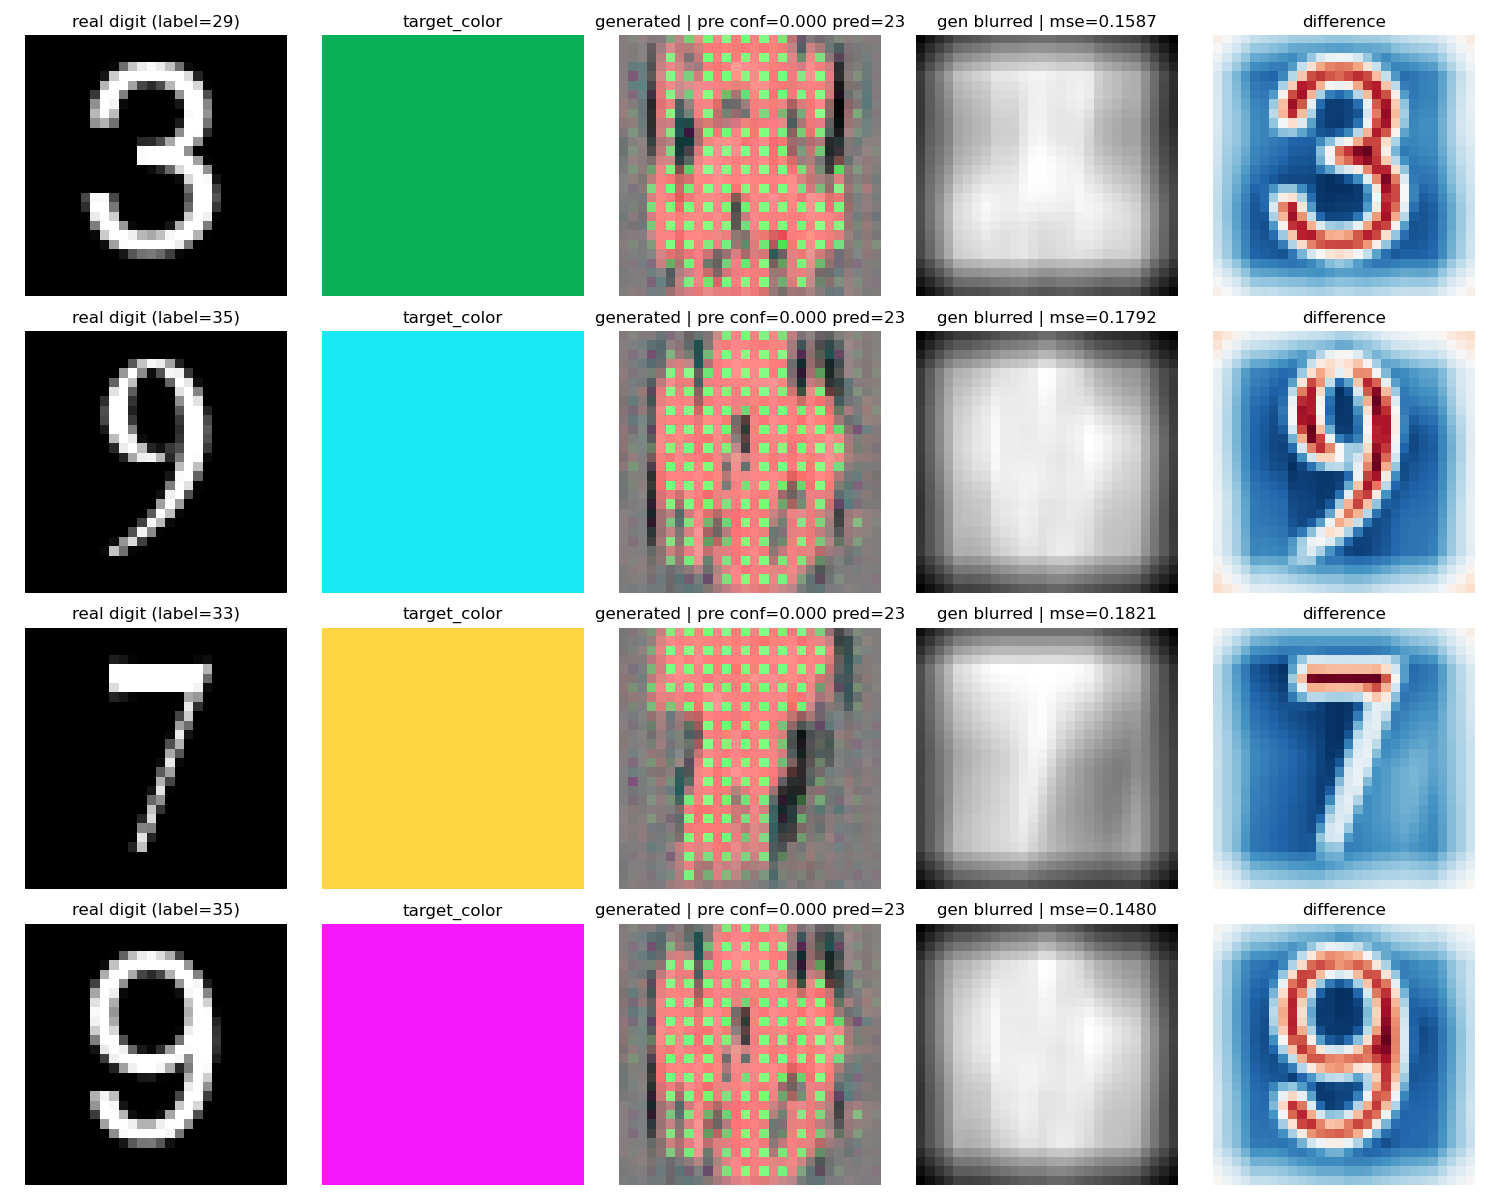

In [24]:
show_generated(model_03_03b, train_set)